---
title: "Intro to EDA"
date: last-modified
toc: true
format:
  html: default
  ipynb: default
---


Exploratory data analysis, or EDA, is a standard practice prior to any data manipulation and analysis.

Recall that data engineering is primarily about data preparation to *serve* smooth and effective data analysis.  Exploratory data analysis generally refers to the step of understanding the data:  

- **summarizing characteristics of raw data**
- **visualizing data (single and multiple variables)**
- identifying missing data
- identifying outliers

This document primarily deals with the first two items.  

## Goals
In the **exploratory** phase, these are for people behind the scenes to see.  

The main goals here are:

- capture main message
- (relatively) quick exploration across many summaries (including plots)
- *not* intended for a client or presentation

What does this translate to, technically?

- each summary should have meaningful information
- **label** your plots

## Data summary
As a starting point, simply looking at the data is worth the while.  Some common questions to consider are the following:  


1. General dataset info: size, dtypes  
2. Missing values?  
3. Duplicate data?  
4. Continuous variables  
5. Categorical variables  
6. Bivariate relationships  
7. Potential data quality issues, e.g., inconsistency, special NA characters

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

|![sns](../img/sns.jpg)|
|:---:|
|[The origin of sns.](https://seaborn.pydata.org/faq.html#why-is-seaborn-imported-as-sns)|

## Earthquake dataset

[Source Link](https://open.canada.ca/data/en/dataset/2c3672b6-4c17-4ff5-9861-29e2dd6d03b3/resource/9cfea46f-561a-440f-9d17-fed3557fc7b5)

In [35]:
# load and save a copy of the earthquake dataset
earthquake = pd.read_csv('https://raw.githubusercontent.com/mosesyhc/de300-2026wi/refs/heads/main/datasets/Canadian-Earthquakes-2010-2019.csv')

In [36]:
# take a glimpse of the data
earthquake.head()

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
0,<2,1.7,ML,2010-01-01T00:16:49+0000,81 km NE of Seattle,0.0,48.192001,-121.677002,1,-121.677315,48.191706
1,2,2.2,MN,2010-01-01T00:52:50+0000,86 km NW from Maniwaki,18.0,47.028999,-76.583000,2,-76.583303,47.028909
2,<2,1.8,MN,2010-01-01T03:21:58+0000,21 km NW from Mont-Laurier,18.0,46.651001,-75.734001,3,-75.733902,46.650809
3,<2,1.5,MN,2010-01-01T04:14:51+0000,CHARLEVOIX SEISMIC ZONE,13.0,47.740002,-69.741997,4,-69.742000,47.740210
4,<2,1.6,ML,2010-01-01T04:15:17+0000,83 km W of Gold R.,11.6,49.500999,-127.222000,5,-127.222216,49.500705


In [37]:
# view a summary of the full data
earthquake.info()

# data types in pandas is specific
# make sure the outputted types are actually what you want/what they should be

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   magnitude_codelist  44561 non-null  object 
 1   magnitude           44561 non-null  float64
 2   magnitude_type      44462 non-null  object 
 3   date                44561 non-null  object 
 4   place               44561 non-null  object 
 5   depth               44561 non-null  float64
 6   latitude            44561 non-null  float64
 7   longitude           44561 non-null  float64
 8   OBJECTID            44561 non-null  int64  
 9   longitude_geom      44561 non-null  float64
 10  latitude_geom       44561 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 3.7+ MB


In [38]:
# checks for duplicates (also ask if duplicates make sense)
earthquake[earthquake.duplicated()]
# .duplicated() returns a boolean

# how does pandas index rows and cols?
# .loc / .iloc
# .loc is label-based, meaning you use the names of rows and columns
# .iloc is integer-position-based, meaning you use their numerical index (0, 1, 2...)

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom


In [39]:
# duplicates


In [40]:
# a quick numerical summary for numerical cols
# earthquake.describe()
earthquake.describe(include='all')

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
count,44561,44561.000000,44462,44561,44561,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000
unique,6,NaN,7,44481,18639,NaN,NaN,NaN,NaN,NaN,NaN
top,<2,NaN,ML,2018-07-02T04:08:13+0000,CHARLEVOIX SEISMIC ZONE,NaN,NaN,NaN,NaN,NaN,NaN
freq,19764,NaN,29509,3,1250,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.134070,NaN,NaN,NaN,12.852194,53.351863,-118.953322,22281.000000,-118.953299,53.351830
std,NaN,0.828096,NaN,NaN,NaN,9.963145,6.214464,23.696484,12863.797009,23.696493,6.214465
min,NaN,-1.400000,NaN,NaN,NaN,-0.500000,40.808998,-148.811005,1.000000,-148.810526,40.808509
25%,NaN,1.600000,NaN,NaN,NaN,5.000000,49.169998,-132.427994,11141.000000,-132.427618,49.170009
50%,NaN,2.100000,NaN,NaN,NaN,10.000000,52.137001,-129.671997,22281.000000,-129.672016,52.136507
75%,NaN,2.700000,NaN,NaN,NaN,18.000000,56.514999,-121.947998,33421.000000,-121.948318,56.515206


In [41]:
# checks for possible statistical assumption(s)
import scipy.stats as sps

sps.normaltest(earthquake['magnitude'])
# normaltest is used as an example in this case
# observation: pvalue is 0

NormaltestResult(statistic=np.float64(1597.6658124732553), pvalue=np.float64(0.0))

In [42]:
# extract only numeric variables
earthquake_num = earthquake.select_dtypes('number')

In [43]:
earthquake_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   magnitude       44561 non-null  float64
 1   depth           44561 non-null  float64
 2   latitude        44561 non-null  float64
 3   longitude       44561 non-null  float64
 4   OBJECTID        44561 non-null  int64  
 5   longitude_geom  44561 non-null  float64
 6   latitude_geom   44561 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.4 MB


In [44]:
# for example, normality test
sps.normaltest(earthquake_num)

NormaltestResult(statistic=array([ 1597.66581247, 15302.56967363,  9387.86913782,  8551.48250207,
       39401.07756051,  8551.48413702,  9387.85609679]), pvalue=array([0., 0., 0., 0., 0., 0., 0.]))

In [45]:
# for example, another normality test
sps.shapiro(earthquake['magnitude'])
# the shapiro test only works for one col

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 44561.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9877396508026011), pvalue=np.float64(1.179774985585813e-49))

In [46]:
# pairwise correlation
earthquake_num = earthquake.select_dtypes('number')
earthquake_num.corr()

# import numpy as np
# earthquake_num = earthquake.select_dtypes('number')
# np.corrcoef(earthquake_num.iloc[:500])

# with large datasets, we go through things locally, but at some point they will be moved to the cloud
# sometimes doing a sample is helpful

,magnitude,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
magnitude,1.000000,-0.127958,0.196699,-0.110731,-0.006523,-0.110731,0.196699
depth,-0.127958,1.000000,-0.107744,-0.005796,-0.103983,-0.005796,-0.107744
latitude,0.196699,-0.107744,1.000000,-0.266265,-0.000391,-0.266265,1.000000
longitude,-0.110731,-0.005796,-0.266265,1.000000,0.049094,1.000000,-0.266265
OBJECTID,-0.006523,-0.103983,-0.000391,0.049094,1.000000,0.049093,-0.000390
longitude_geom,-0.110731,-0.005796,-0.266265,1.000000,0.049093,1.000000,-0.266265
latitude_geom,0.196699,-0.107744,1.000000,-0.266265,-0.000390,-0.266265,1.000000


## Data visualization

In [47]:
sns.set(context='talk', style='ticks')  # simply for aesthetics
sns.set_palette('magma')
%matplotlib inline

# earthquake = earthquake.sample(n=500)  # (if too slow) for illustration purposes
# above is used when looking for a rough idea of the dataset aka sample

<Axes: ylabel='Frequency'>

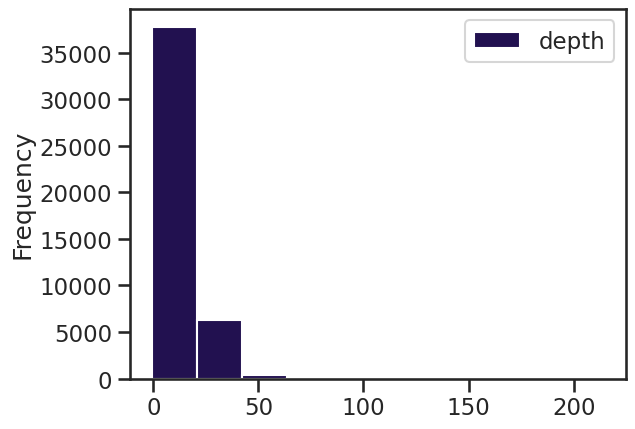

In [48]:
# histogram for continuous variables using pandas built-in plots
earthquake.plot.hist(column='depth')

<Axes: xlabel='depth', ylabel='Probability'>

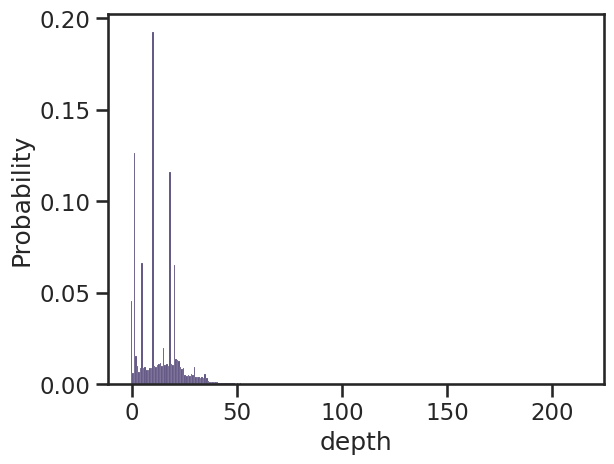

In [58]:
# relative frequency? ...
sns.histplot(x='depth', data=earthquake, stat='probability')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   magnitude_codelist  44561 non-null  object 
 1   magnitude           44561 non-null  float64
 2   magnitude_type      44462 non-null  object 
 3   date                44561 non-null  object 
 4   place               44561 non-null  object 
 5   depth               44561 non-null  float64
 6   latitude            44561 non-null  float64
 7   longitude           44561 non-null  float64
 8   OBJECTID            44561 non-null  int64  
 9   longitude_geom      44561 non-null  float64
 10  latitude_geom       44561 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 3.7+ MB


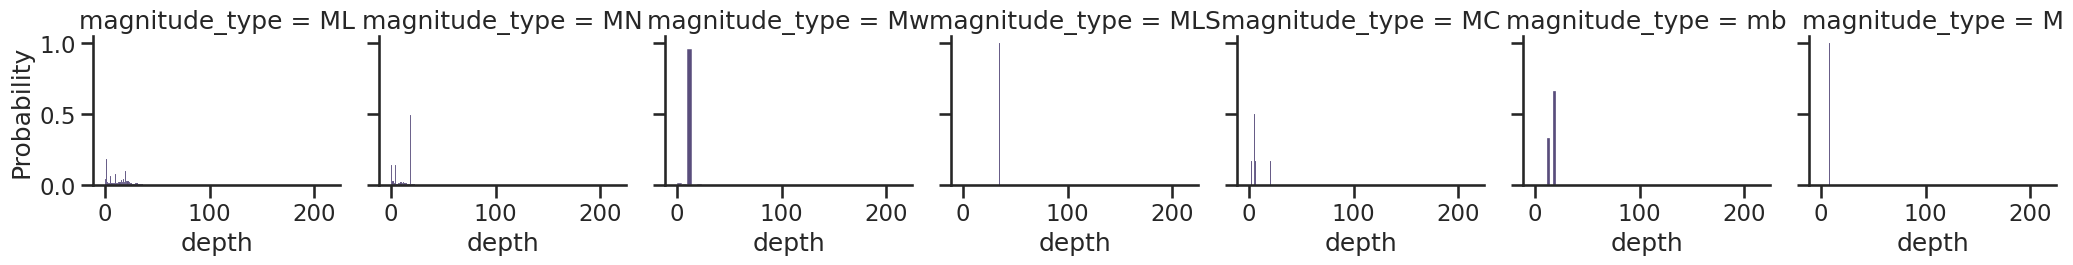

In [63]:
# histogram of masses by group
earthquake.info()
g = sns.FacetGrid(earthquake, col='magnitude_type')
# A Seaborn FacetGrid is a multi-plot grid that visualizes the distribution of
# variables or relationships between multiple variables by creating subsets of
# a dataset across rows, columns

g.map(sns.histplot, 'depth', stat="probability")

In [64]:
# other types of plots

earthquake.info()
g = sns.FacetGrid(earthquake, col='magnitude_type', sharex=False) # sharex=False makes the grids have the same scale

g.map(sns.violinplot= 'depth')

SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (877509921.py, line 6)

In [52]:
# counts for categorical variables


In [53]:
# barplots by group
sns.barplot(x='magnitude_type', y='depth', data=earthquake)

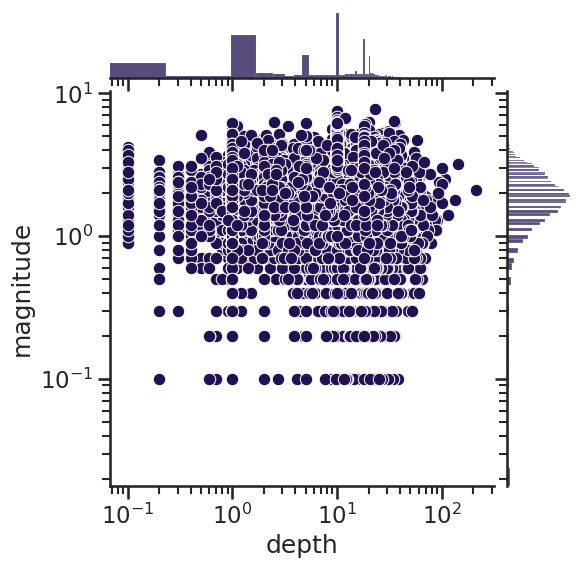

In [66]:
# bivariate plots
sns.jointplot(x='depth', y='magnitude', data=earthquake)

# jointplot is most useful for loooking at correlations / dependent behaviors

plt.xscale('log')
plt.yscale('log')
# you can change the scale to show a bit more of a bell shape

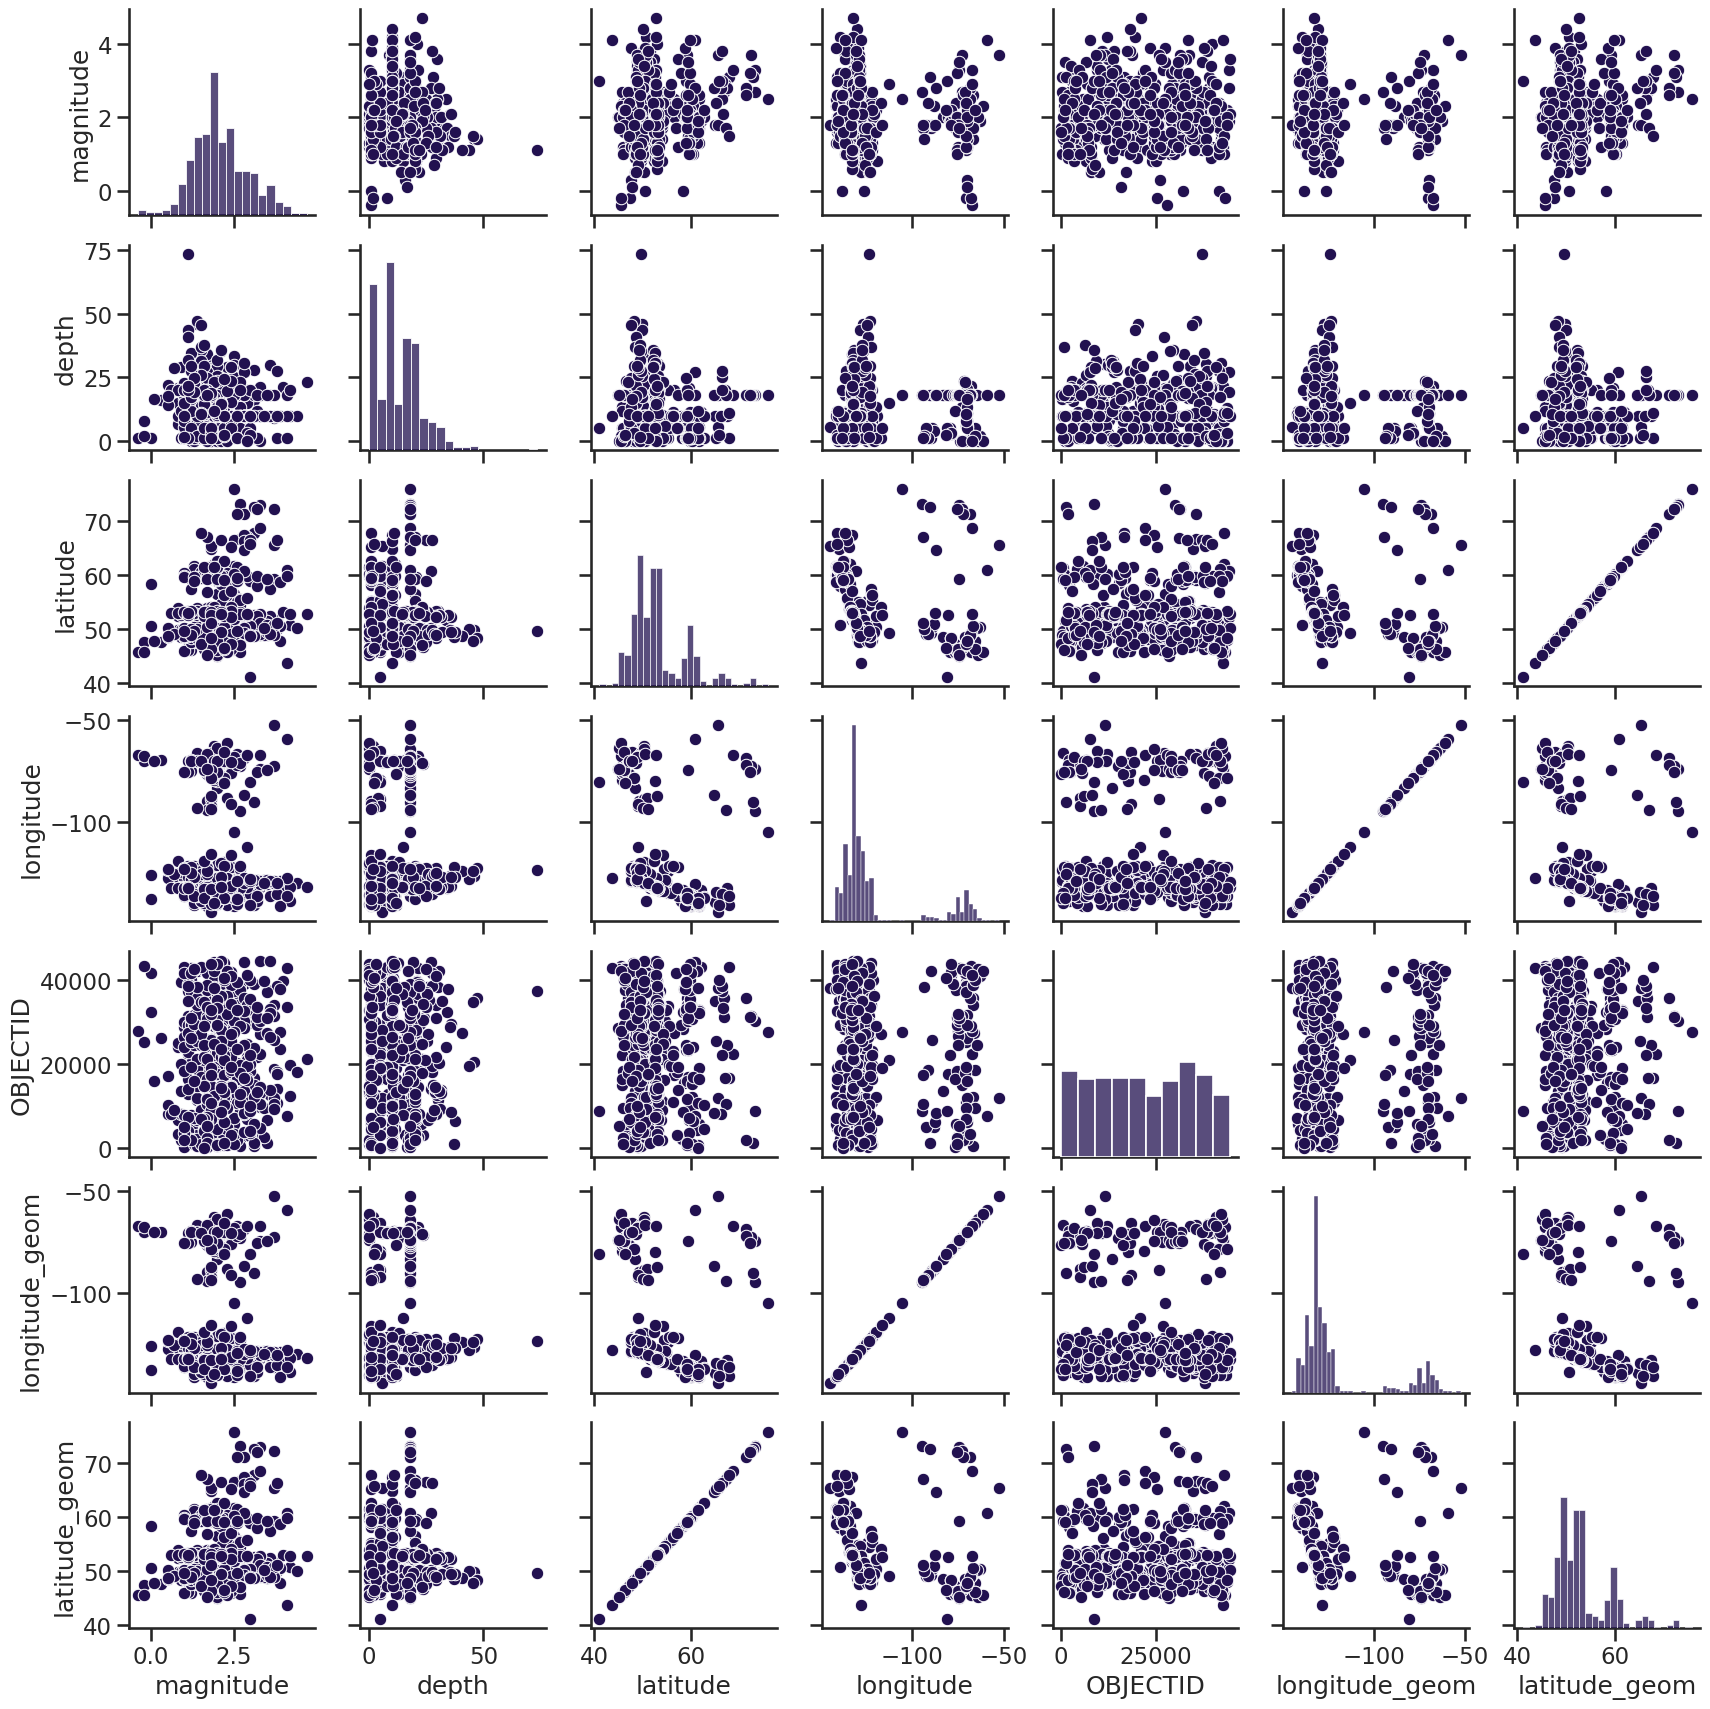

In [68]:
# bivariate plots (log-log)
g= sns.pairplot(earthquake.sample(500))

# always use some sample for pairplot
# never go above 500 with 7 dimension

In [56]:
# pairwise plots  (time-consuming)

# over different magnitude type, give them distinguishing colors

In [57]:
# another pairwise plot by group

## (In case you need this) Jupyter notebook setup

Visit https://docs.jupyter.org/en/latest/install/notebook-classic.html for some guidance to set up jupyter notebook.

## In-class activity
Refer to the following figure, choose two subfigures to reproduce with the earthquake dataset.

![](../datasets/earthquake_analysis-2010-2019.png)


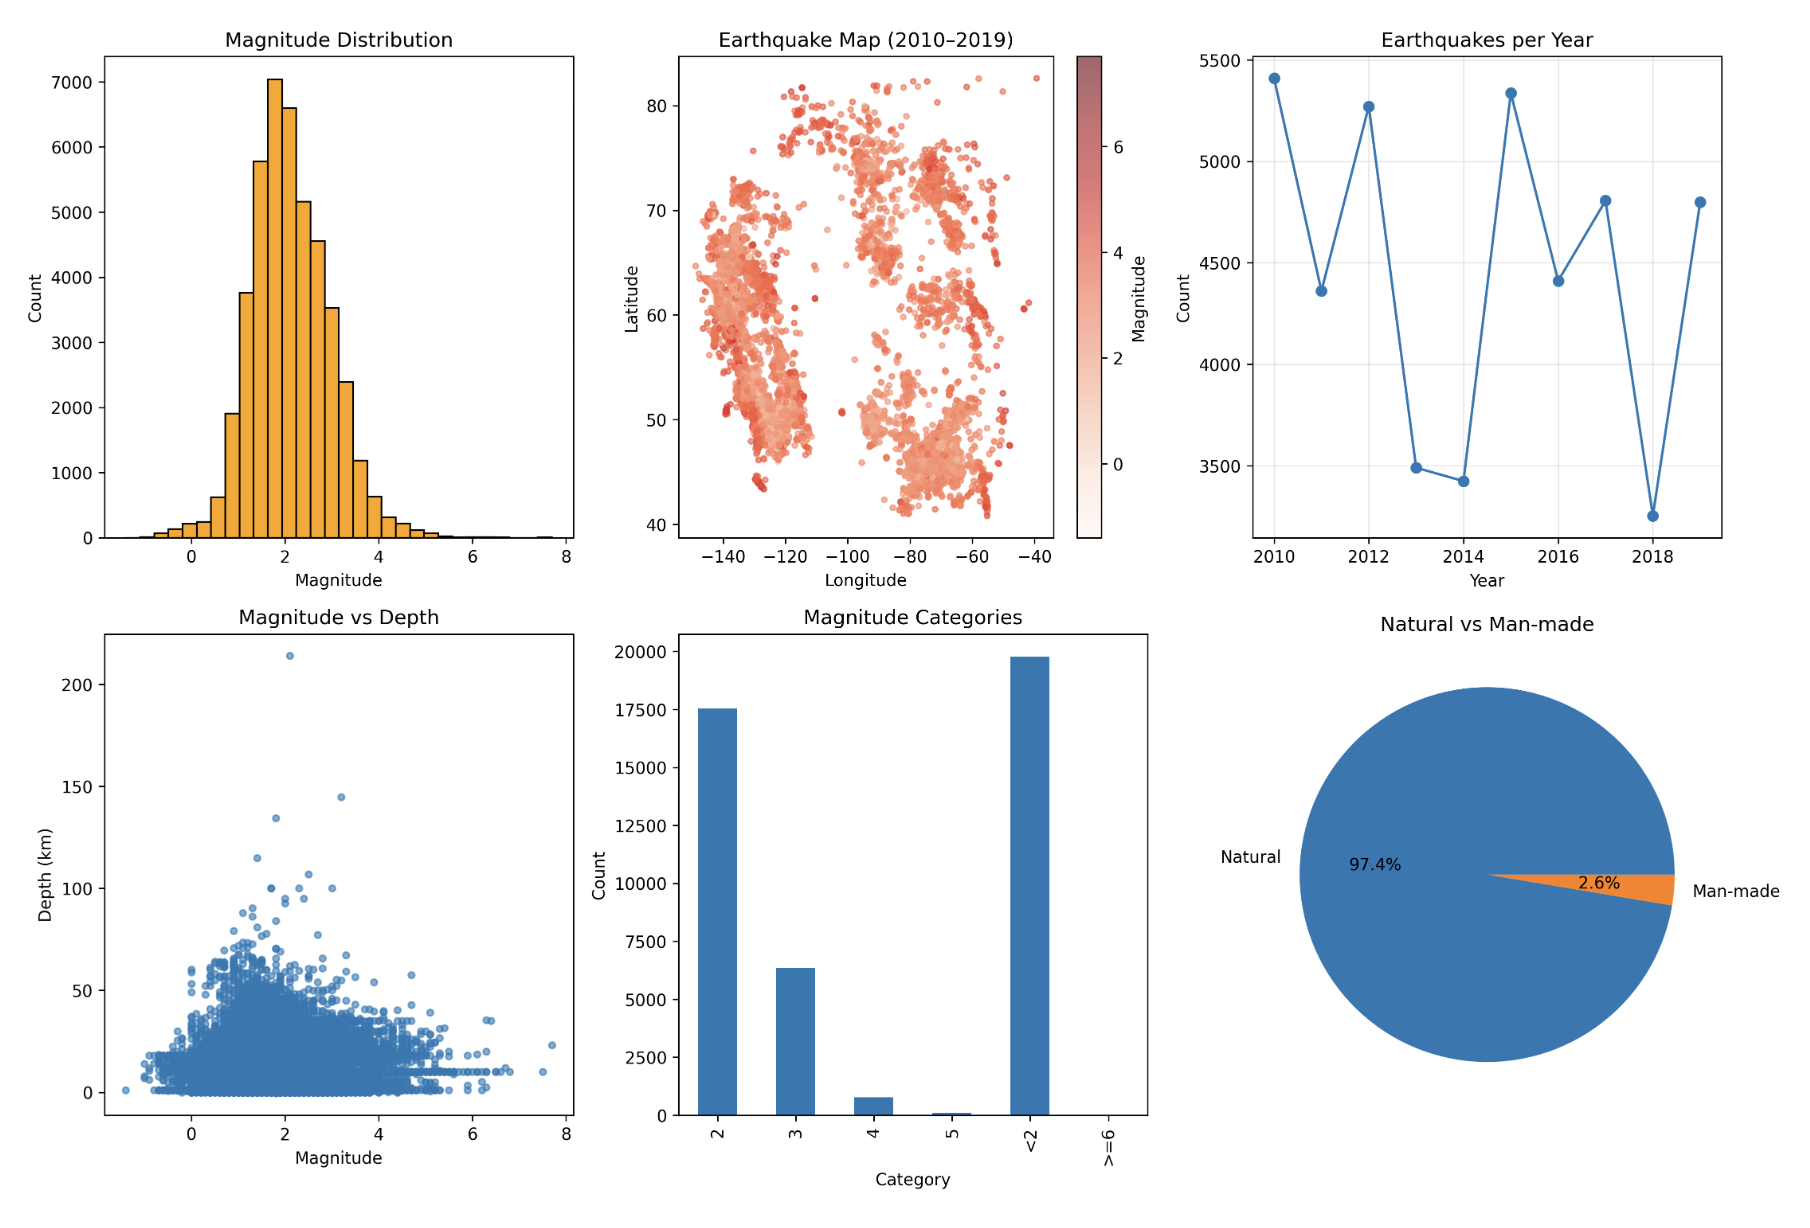

(0.0, 7000.0)

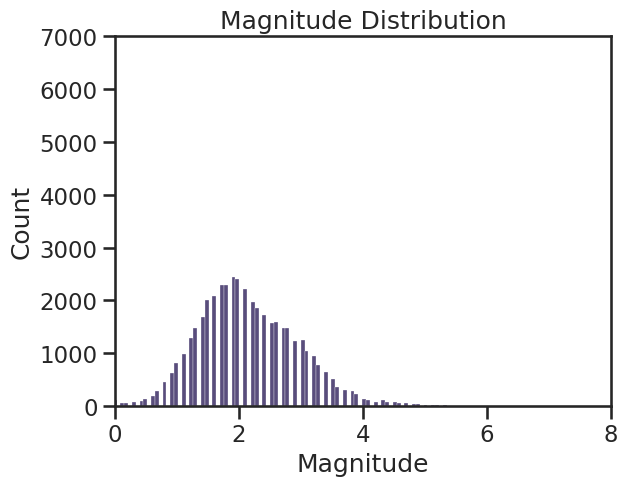

In [80]:
plot = sns.histplot(x='magnitude', data=earthquake, stat='count')
plot.set_xlabel('Magnitude')
plot.set_ylabel('Count')
plot.set_title('Magnitude Distribution')

plot.set_xlim(0, 8)   # x-axis range
plot.set_ylim(0, 7000)  # y-axis range

Text(0.5, 1.0, 'Magnitude vs Depth')

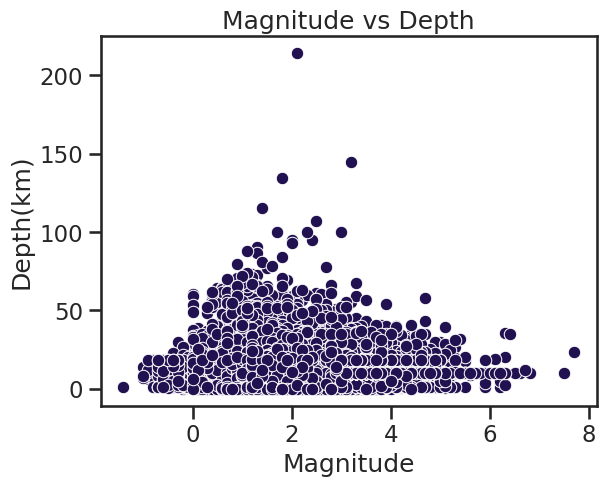

In [77]:
scatterplot = sns.scatterplot(data=earthquake, x='magnitude', y = 'depth')
scatterplot.set_xlabel('Magnitude')
scatterplot.set_ylabel('Depth(km)')
scatterplot.set_title('Magnitude vs Depth')


---

*Note:* These notes are adapted from a blog post on [Tom's Blog](https://tomaugspurger.net/posts/modern-6-visualization/).
